In [6]:
import torch
from torch.nn import Module, ModuleList, Parameter, Buffer
import tiktoken
import math
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
print('Hello World')

Hello World


# Training your LLM

### Cross Entropy Loss

Recall that the cross entropy loss is defined, for $\hat{y} \in \mathbb{R}^k$ and $y \in \{1,\ldots,k\}$ as
$$L_{ce}(\hat{y}, y) = -\log \left ( \frac{\exp \hat{y}_y}{\sum_{j=1}^k \exp \hat{y}_j} \right ) = -\hat{y}_y + \log \sum_{j=1}^k \exp \hat{y}_j$$

In [7]:
def cross_entropy_loss(logits, y):
    """
    Compute avg cross entropy loss over a minibatch
    Inputs:
        logits : ND torch.Tensor[float] (... x k) - predicted logits for each example
        y : (N-1)D torch.Tensor[int] (...) - desired class for each example
    Output:
        scalar torch.Tensor[float] - average cross entropy loss
    """
    logits_2D = logits.reshape(-1, logits.shape[-1])
    y_1D = y.reshape(-1)
    y_hat_y = torch.gather(logits_2D,1,y_1D.unsqueeze(1)).squeeze(1)
    loss = - y_hat_y + torch.logsumexp(logits_2D, dim=1)
    return loss.mean()

### Optimization (Stochastic Gradient Descent) 

The goal of optimization is to find the best values for the **weights** that minimize the loss on the training set.

The **`SGD` update rule** is:

$$
w := w - \eta \, \nabla L_\text{CE}(w \cdot x_i, y_i)
$$

Where:

- $w$ → weight matrix  
- $\eta$ → learning rate  (step size)
- $L_\text{CE}$ → cross-entropy loss  
- $(x_i, y_i)$ → a training sample (or mini-batch)

In [8]:
class SGD:
    def __init__(self,parameters,learning_rate):
        """
        Initialize an SGD optimizer over a set of model parameters.

        Inputs:
            parameters: iterable[torch.nn.Parameter] - parameters to optimize
            learning_rate : float - gradient descent step size
        """
        self.parameters = list(parameters)
        #model.parameters() generates an object that produces values one at a time, 
        #and once they are used, they're gone. Therefore we store it in a list so that we
        #can iterate
        self.learning_rate = learning_rate

    def step(self):
        """
        Apply one SGD update to all stored parameters.
        """
        with torch.no_grad(): #parameters update here
            for w in self.parameters:
                if w.grad is not None: 
                    w -= self.learning_rate * w.grad

    def zero_grad(self):
        """
        Zero out gradients for all stored parameters when gradients exists.
        """
        for w in self.parameters:
            if w.grad is not None:
                w.grad.zero_()
                

## Gradient Descent Visualization

In this section, we visualize how gradient descent updates parameters while minimizing a simple quadratic function.

The derivative tells us the slope of the function at a given point and is used to determine the update direction during optimization.

---
## Objective

Gradient descent attempts to find the minimum of the function by repeatedly updating:

$$
x_{new} = x - \eta f'(x)
$$

where:

- \(x\) = current parameter value
- $\eta$ = `learning rate`
- \(f'(x)\) = gradient (slope)

---

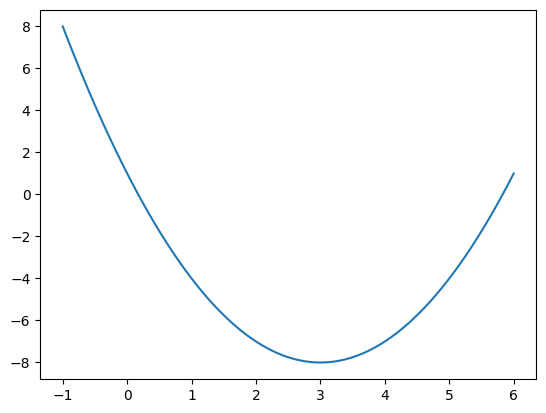

In [19]:
def f(x):
    return x**2 - 6*x + 1
def f_prime(x):
    return 2*x - 6
X = torch.linspace(-1,6,100)
plt.plot(X,f(X));

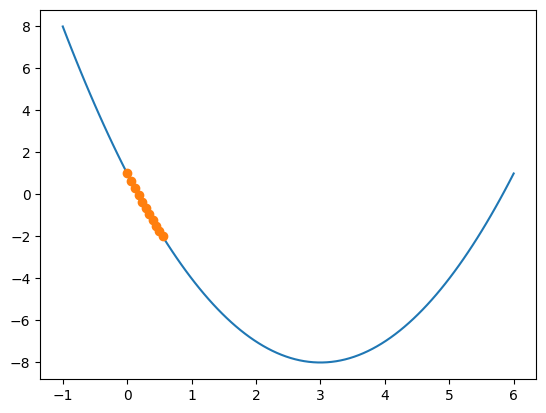

In [22]:
x_iters = [0]
for i in range(10):
    x = x_iters[-1]
    x_new = x - 0.01*f_prime(x)
    x_iters.append(x_new)
x_iters = torch.tensor(x_iters)
plt.figure()
plt.plot(X,f(X))
plt.plot(x_iters, f(x_iters), '-o');

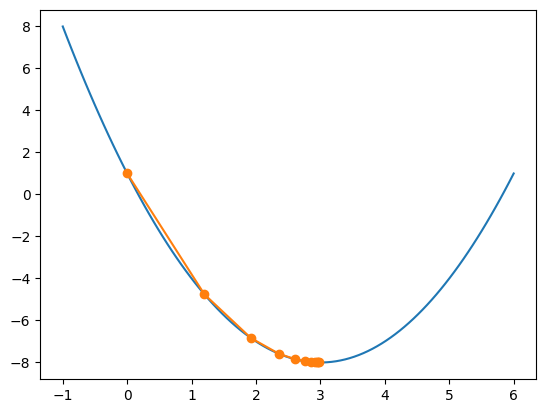

In [23]:
x_iters = [0]
for i in range(10):
    x = x_iters[-1]
    x_new = x - 0.2*f_prime(x)
    x_iters.append(x_new)
x_iters = torch.tensor(x_iters)
plt.figure()
plt.plot(X,f(X))
plt.plot(x_iters, f(x_iters), '-o');

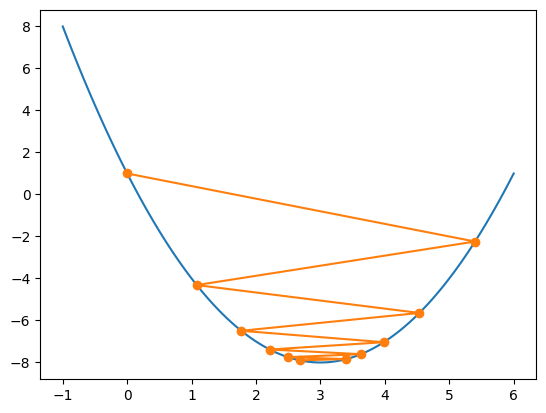

In [24]:
x_iters = [0]
for i in range(10):
    x = x_iters[-1]
    x_new = x - 0.9*f_prime(x)
    x_iters.append(x_new)
x_iters = torch.tensor(x_iters)
plt.figure()
plt.plot(X,f(X))
plt.plot(x_iters, f(x_iters), '-o');

## Key Insight

* Choosing an appropriate learning rate is critical:

1. Too small → training becomes very slow
2. Too large → optimization becomes unstable

In [27]:
def f(x1,x2):
    return 2*x1**2 + 3*x2**2 - 2*x1*x2 - 3*x1 + 5*x2 + 4
def df_x1(x1,x2):
    return 4*x1 - 2*x2 - 3
def df_x2(x1,x2):
    return 6*x2 - 2*x1 + 5

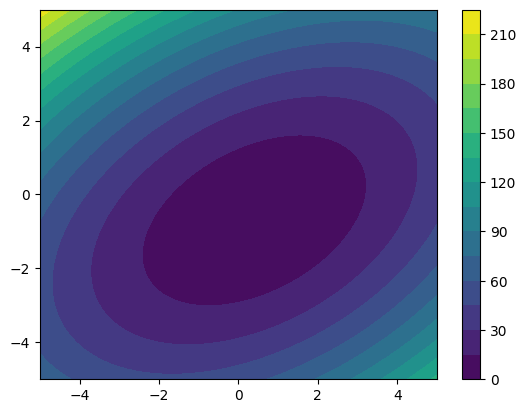

In [31]:
X1, X2 = torch.meshgrid(torch.linspace(-5,5,100), torch.linspace(-5,5,100))
plt.contourf(X1,X2,f(X1,X2),20)
plt.colorbar();

### You can see the function has minimum (very dark violet) around (0,0) and increase a lot as up towards the side.

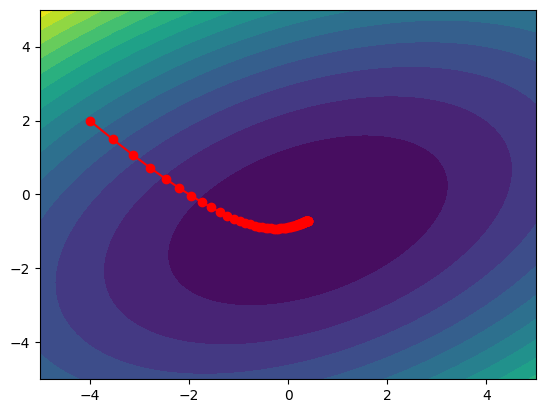

In [35]:
x_iters = [torch.tensor([-4,2])] #iteration 0 starts at point: (-4,2)
eta = 0.02
for i in range(100):
    x1,x2 = x_iters[-1]
    x1_new = x1 - eta*df_x1(x1,x2)
    x2_new = x2 - eta*df_x2(x1,x2)
    x_iters.append(torch.tensor([x1_new,x2_new]))
x_iters = torch.stack(x_iters, dim=1)
### Before stacking:
# iteration 0: [-4, 2]
# iteration 1: [-3, 1.5]
# iteration 2: [-2, 1]
### After stacking:
 # [ -4 -3 -2
 #    2 1.5 1]
### why stacking?
# x_iters[0] : gives all the x-values
# x_iters[1] : gives all the y-values
plt.figure()
plt.contourf(X1,X2,f(X1,X2),20)
plt.plot(x_iters[0],x_iters[1], 'r-o');

# Limitations of SGD

Although SGD is simple and effective, it has several practical limitations when training deep neural networks and large language models.

### 1. Sensitive to the Learning Rate

A small learning rate:

- makes training very slow

A large learning rate:

- causes instability
- may overshoot minima
- can diverge

Choosing the correct learning rate becomes difficult.

---

### 2. Same Learning Rate for Every Parameter

SGD applies the same update scale to all parameters:

However, different parameters may require different update magnitudes.

---

# Why Adam Works Better

Adam (**Adaptive Moment Estimation**) improves optimization by combining:

- Momentum (smooths the update, reduces the "bounce around")
- Adaptive learning rates

# Adam Optimizer
- Implement the Adam Optimizer. Recall that the Adam updates are given by:
    
$$
\begin{split}
u & := \beta_1 u + (1-\beta_1) \nabla_W \text{Loss} \\
v & := \beta_2 v + (1-\beta_2) \nabla_W \text{Loss}^2 \quad \text{(square applied elementwise)} \\
\hat{u} & := u / (1 - \beta_1^t) \\
\hat{v} & := v / (1 - \beta_2^t) \\
w & := w - \eta \frac{\hat{u}}{\sqrt{\hat{v}} + \epsilon}  \quad \text{(division done elementwise)}  \\
\end{split}
$$

We'll implement this in the same fashion on the SGD optimization: implement an `__init__()`, `__step__()` (which updates parameters in place), and `zero_grad()` (which clears the gradients of all parameters).

1. In the init function, we should explicitly call `list()` on the `parameters` input to store it in our class (and in the case of Adam, form similar lists for `u` and `v` objectives). This is because the `model.parameters()` function returns a Python generator, an object that can be iterated over one time to return all its elements. So if you only store the passed `parameters` variable and then try to iterate over it during your `zero_grad` or `step` functions, you will only iterate over the parameters one time, and thereafter there won't be any elements to iterate over.

2. We need to compute the updates to the parameters within a `torch.no_grad()` block, as `with torch.no_grad()`.


In [36]:
class Adam:
    def __init__(self, params, lr=1e-3, betas = (0.9, 0.999), eps=1e-8):
        """
        Initialize Adam optimizer state for a set of parameters.
        Inputs:
            params: iterable[torch.nn.parameter] - parameters to optimize
            lr: float - learning rate
            betas: tuple(float, float) - decay rates for first and second moments
            eps: float - numerical stability constant
        """
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps

        self.u = [torch.zeros(p.shape) for p in self.params]
        self.v = [torch.zeros(p.shape) for p in self.params]
        self.t = 0
    def step(self):
        """
        Apply one adam update to all stored parameter.
        """
        self.t += 1
        with torch.no_grad():
            for i,p in enumerate(self.params):
                if p.grad is not None:
                    self.u[i] = self.beta1 * self.u[i] + (1-self.beta1) * p.grad
                    self.v[i] = self.beta2 * self.v[i] + (1-self.beta2) * (p.grad**2)
                    u_hat = self.u[i] / (1-self.beta1**self.t)
                    v_hat = self.v[i] / (1-self.beta2**self.t)
                    p -= self.lr * u_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        """
        Zero out gradients for all stored parameters when gradients exist.
        """
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

# Key Insight

SGD helps us understand the core idea of gradient-based optimization.

Adam extends this idea with momentum and adaptive scaling, making it far more effective for training deep neural networks and transformers.